# ViEcomIntent — Dataset Evaluation Notebook

**Mục tiêu:** Thực hiện Phase 1 Data Audit theo `docs/paper_plan.md`
- Biết chính xác dataset đang có gì, thiếu gì
- Phân tích phân phối nhãn (L1/L2/L3)
- Đánh giá chất lượng QA status
- Xác định intents thiếu mẫu (< 30) và thừa mẫu (> 200)
- Export `data/audit/intent_distribution.csv`

**Nguồn dữ liệu:** `data/raw/hasaki_labelled_full.json`  
**Taxonomy:** `data/unified_intents.csv` + `data/intent_hierachy.json`

## 0. Setup

In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path("../")  # adjust if running from a different location
LABELLED_JSON   = ROOT / "data/raw/hasaki_labelled_full.json"
TAXONOMY_CSV    = ROOT / "data/unified_intents.csv"
HIERARCHY_JSON  = ROOT / "data/intent_hierachy.json"
AUDIT_DIR       = ROOT / "data/audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11
sns.set_theme(style="whitegrid")

print("Setup done.")

Setup done.


## 1. Load Data

In [2]:
import subprocess

def _load_labelled_json(path: Path):
    """Load labelled JSON; falls back to git HEAD if working-tree file is empty."""
    raw_bytes = path.read_bytes() if path.exists() else b""
    if raw_bytes.strip():
        return json.loads(raw_bytes)
    print(f"WARNING: {path} is empty — loading from git HEAD instead.")
    result = subprocess.run(
        ["git", "show", f"HEAD:{path.relative_to(ROOT)}"],
        capture_output=True, text=True, cwd=ROOT
    )
    if result.returncode != 0:
        raise FileNotFoundError(f"File missing and git show failed: {result.stderr}")
    return json.loads(result.stdout)

raw = _load_labelled_json(LABELLED_JSON)

meta_stats = raw.get("stats", {})
results    = raw.get("results", [])

print(f"Run mode : {raw.get('run_mode')}")
print(f"Num labelled: {raw.get('num_labelled')}")
print(f"Source size : {raw.get('num_samples_in_source')}")
print()
print("Pipeline QA stats (raw metadata):")
for k, v in meta_stats.items():
    print(f"  {k}: {v}")

Run mode : full_hasaki_prelabel
Num labelled: 2043
Source size : 2043

Pipeline QA stats (raw metadata):
  approved: 1603
  approved_auto_new_label: 158
  needs_review: 81
  pending_new_label_review: 169
  pending_new_label_invalid_slug: 25
  skipped_ambiguous: 7


In [3]:
# Build tidy dataframe
rows = []
for r in results:
    il = r.get("intent_3_level") or {}
    rows.append({
        "sample_id" : r.get("sample_id", ""),
        "sentence"  : r.get("sentence", ""),
        "category"  : r.get("category", ""),
        "l1"        : il.get("level_1", ""),
        "l2"        : il.get("level_2", ""),
        "l3"        : il.get("level_3", ""),
        "confidence": r.get("confidence"),
        "qa_status" : r.get("qa_status", ""),
        "reasoning" : r.get("reasoning", ""),
        "has_error"  : r.get("error") is not None,
    })

df = pd.DataFrame(rows)
df["word_count"] = df["sentence"].str.split().str.len()
df["char_count"] = df["sentence"].str.len()

print(f"Total rows : {len(df)}")
df.head(3)

Total rows : 2043


,sample_id,sentence,category,l1,l2,l3,confidence,qa_status,reasoning,has_error,word_count,char_count
0,sua-rua-mat-cerave-sach-sau-cho-da-thuong-den-...,Mình mới nhận đơn hàng 2604085OA8MCMG mà thấy ...,Sức khỏe làm đẹp,sau_mua_hang,khieu_nai_dich_vu,khieu_nai_nhan_vien_cua_hang,0.95,approved,Câu hỏi của khách thể hiện sự không hài lòng v...,False,137,650
1,sua-rua-mat-cerave-sach-sau-cho-da-thuong-den-...,shop ơi gửi đơn sớm cho mìn dc ko,Sức khỏe làm đẹp,sau_mua_hang,trang_thai_van_chuyen,yeu_cau_giao_nhanh,0.95,approved,"Câu hỏi của khách yêu cầu gửi đơn hàng sớm, ch...",False,9,33
2,sua-rua-mat-cerave-sach-sau-cho-da-thuong-den-...,Vậy là sao nv bên bạn nghĩ mih k bít gì hay sa...,Sức khỏe làm đẹp,sau_mua_hang,khieu_nai_dich_vu,khieu_nai_nhan_vien_cua_hang,0.95,approved,Câu hỏi của khách thể hiện sự không hài lòng v...,False,31,121


## 2. QA Status Distribution

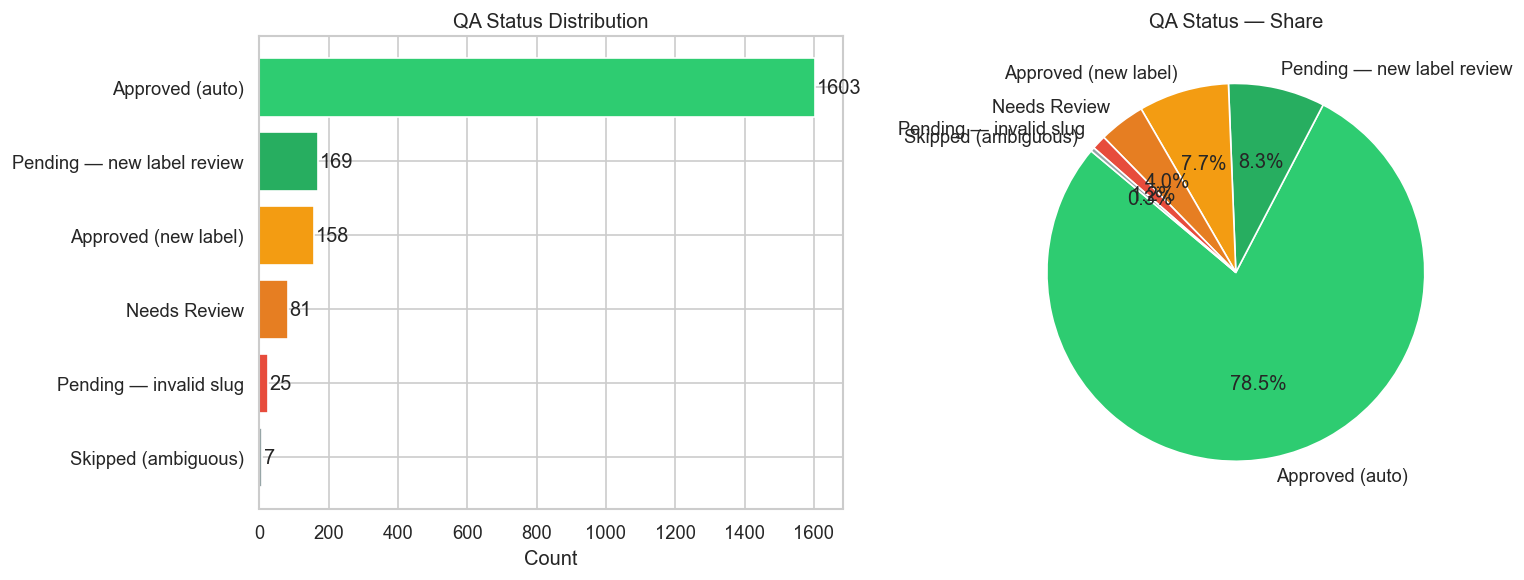


Usable samples (approved): 1761 / 2043 (86.2%)


In [4]:
qa_counts = df["qa_status"].value_counts()

# Readable labels
QA_LABELS = {
    "approved"                    : "Approved (auto)",
    "approved_auto_new_label"      : "Approved (new label)",
    "needs_review"                : "Needs Review",
    "pending_new_label_review"    : "Pending — new label review",
    "pending_new_label_invalid_slug": "Pending — invalid slug",
    "skipped_ambiguous"           : "Skipped (ambiguous)",
    ""                            : "Unknown / empty",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
labels = [QA_LABELS.get(s, s) for s in qa_counts.index]
colors = ["#2ecc71", "#27ae60", "#f39c12", "#e67e22", "#e74c3c", "#95a5a6", "#bdc3c7"]
axes[0].barh(labels, qa_counts.values, color=colors[:len(labels)])
for i, v in enumerate(qa_counts.values):
    axes[0].text(v + 5, i, str(v), va="center")
axes[0].set_xlabel("Count")
axes[0].set_title("QA Status Distribution")
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(qa_counts.values, labels=labels, colors=colors[:len(labels)],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("QA Status — Share")

plt.tight_layout()
plt.savefig(AUDIT_DIR / "qa_status_distribution.png", bbox_inches="tight")
plt.show()

usable = df[df["qa_status"].isin(["approved", "approved_auto_new_label"])]
print(f"\nUsable samples (approved): {len(usable)} / {len(df)} ({len(usable)/len(df)*100:.1f}%)")

## 3. Intent Taxonomy Analysis

### 3.1 L1 Distribution (trước_mua vs sau_mua)

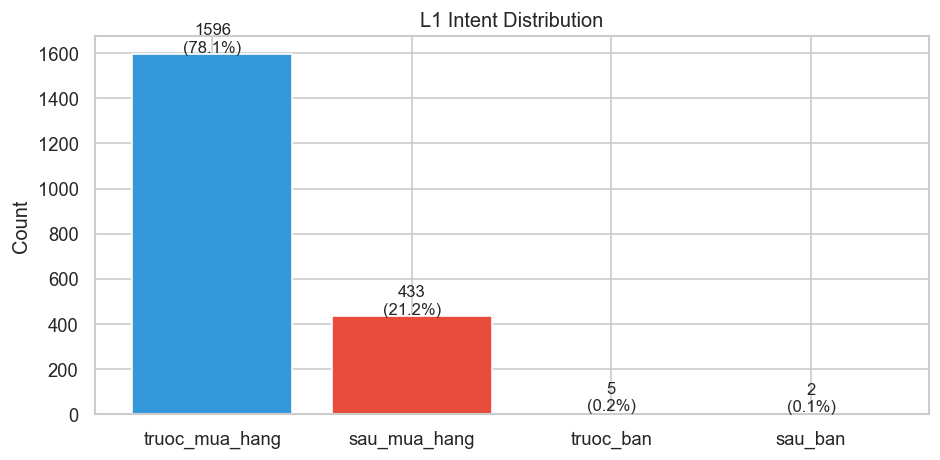

Target ratio before_sale:after_sale = 60%:40%
  truoc_mua_hang: 1596 (78.1%)
  sau_mua_hang: 433 (21.2%)
  truoc_ban: 5 (0.2%)
  sau_ban: 2 (0.1%)


In [5]:
l1_counts = df[df["l1"] != ""]["l1"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(l1_counts.index, l1_counts.values,
              color=["#3498db", "#e74c3c", "#95a5a6", "#bdc3c7"][:len(l1_counts)])
for bar, val in zip(bars, l1_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{val}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_title("L1 Intent Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(AUDIT_DIR / "l1_distribution.png", bbox_inches="tight")
plt.show()

print("Target ratio before_sale:after_sale = 60%:40%")
for k, v in l1_counts.items():
    print(f"  {k}: {v} ({v/len(df)*100:.1f}%)")

### 3.2 L2 Distribution

Unique L2 intents in data: 55


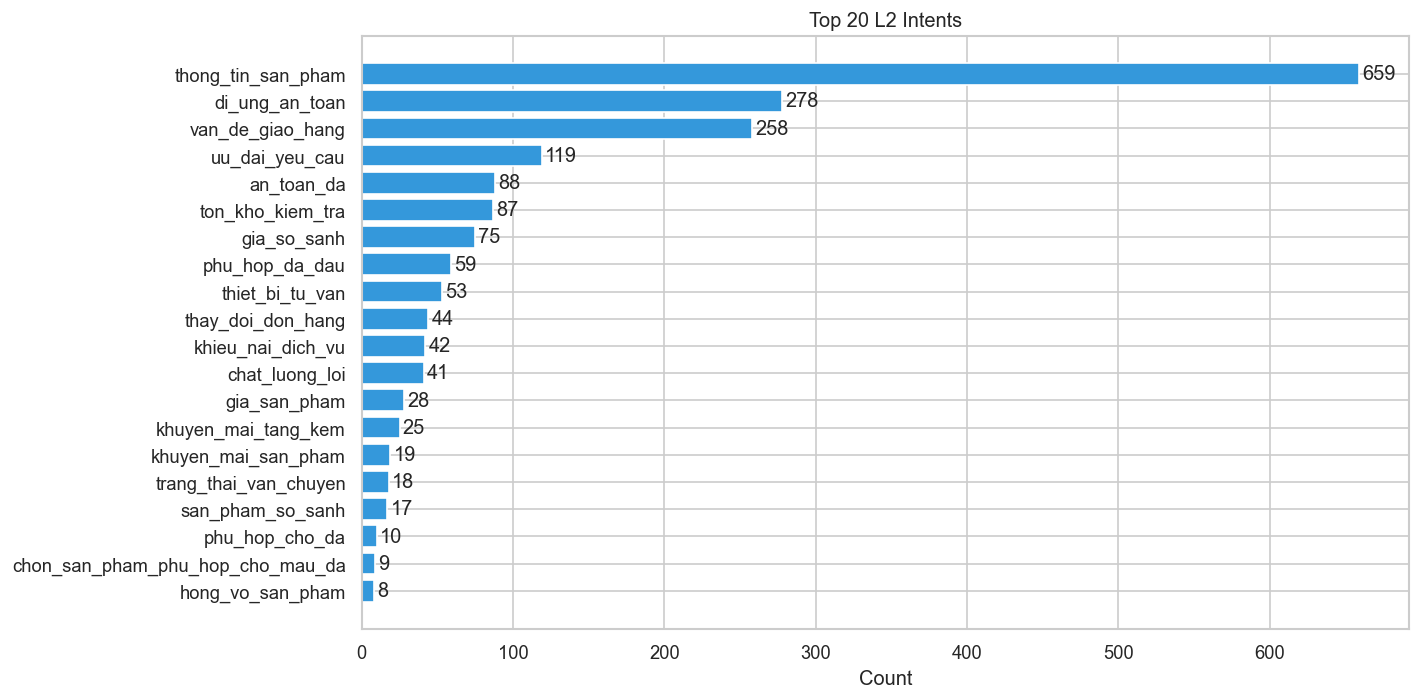

In [6]:
l2_counts = df[df["l2"] != ""]["l2"].value_counts()
print(f"Unique L2 intents in data: {len(l2_counts)}")

# Show top 20
top_l2 = l2_counts.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_l2.index[::-1], top_l2.values[::-1], color="#3498db")
for bar, val in zip(bars, top_l2.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va="center")
ax.set_xlabel("Count")
ax.set_title("Top 20 L2 Intents")
plt.tight_layout()
plt.savefig(AUDIT_DIR / "l2_distribution_top20.png", bbox_inches="tight")
plt.show()

### 3.3 L3 Distribution (tất cả)

Unique L3 intents in data: 366
Expected from taxonomy  : ~50 (paper plan target)


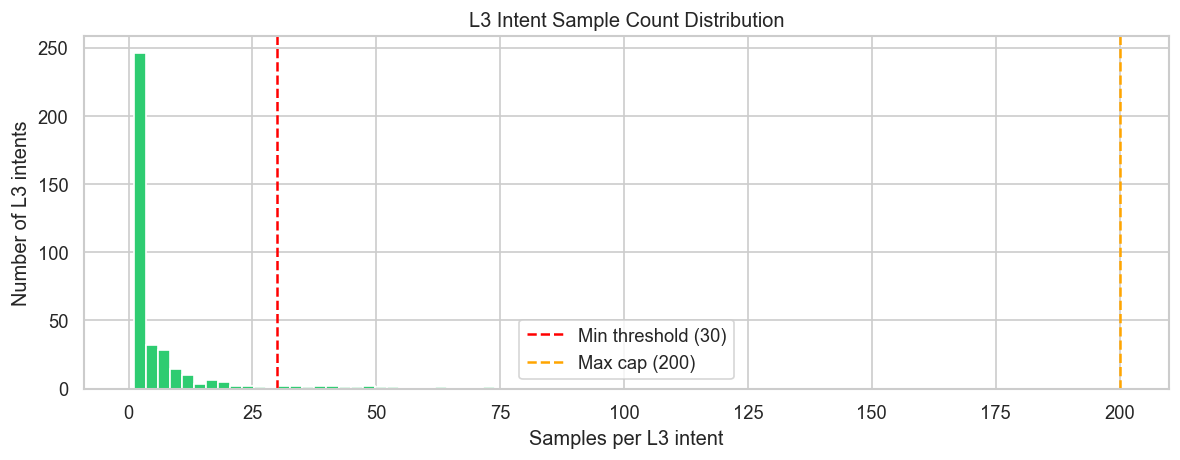


L3 intents with >= 30 samples  : 17
L3 intents with  < 30 samples  : 349 ← need augmentation
L3 intents with > 200 samples  : 0 ← need down-sampling
L3 intents with 1 sample       : 179


In [7]:
l3_counts = df[df["l3"] != ""]["l3"].value_counts()
print(f"Unique L3 intents in data: {len(l3_counts)}")
print(f"Expected from taxonomy  : ~50 (paper plan target)")

# Full histogram of sample counts
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(l3_counts.values, bins=30, color="#2ecc71", edgecolor="white")
ax.axvline(30, color="red", linestyle="--", label="Min threshold (30)")
ax.axvline(200, color="orange", linestyle="--", label="Max cap (200)")
ax.set_xlabel("Samples per L3 intent")
ax.set_ylabel("Number of L3 intents")
ax.set_title("L3 Intent Sample Count Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(AUDIT_DIR / "l3_sample_histogram.png", bbox_inches="tight")
plt.show()

print(f"\nL3 intents with >= 30 samples  : {(l3_counts >= 30).sum()}")
print(f"L3 intents with  < 30 samples  : {(l3_counts < 30).sum()} ← need augmentation")
print(f"L3 intents with > 200 samples  : {(l3_counts > 200).sum()} ← need down-sampling")
print(f"L3 intents with 1 sample       : {(l3_counts == 1).sum()}")

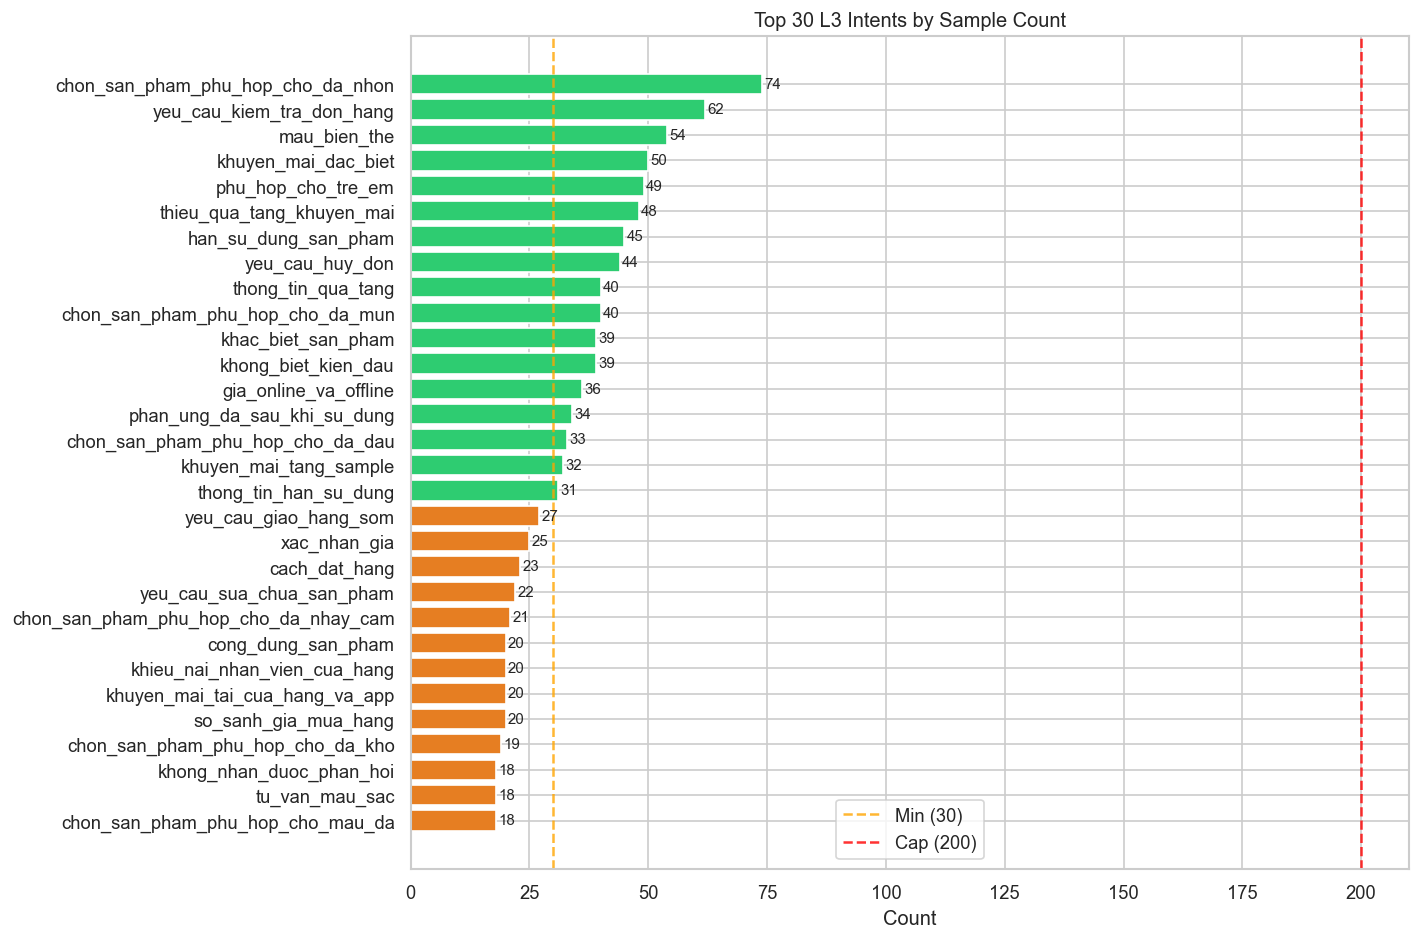

In [8]:
# Top 30 L3 intents
top30 = l3_counts.head(30)
fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = ["#e74c3c" if v > 200 else ("#2ecc71" if v >= 30 else "#e67e22")
              for v in top30.values]
ax.barh(top30.index[::-1], top30.values[::-1], color=colors_bar[::-1])
ax.axvline(30, color="orange", linestyle="--", alpha=0.8, label="Min (30)")
ax.axvline(200, color="red", linestyle="--", alpha=0.8, label="Cap (200)")
for i, v in enumerate(top30.values[::-1]):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Count")
ax.set_title("Top 30 L3 Intents by Sample Count")
ax.legend()
plt.tight_layout()
plt.savefig(AUDIT_DIR / "l3_top30.png", bbox_inches="tight")
plt.show()

## 4. Taxonomy Alignment Check

So sánh L3 intents trong data với taxonomy chính thức (`unified_intents.csv`).

In [9]:
taxonomy_df = pd.read_csv(TAXONOMY_CSV)
print("Taxonomy CSV columns:", list(taxonomy_df.columns))
print(f"Total intents in taxonomy: {len(taxonomy_df)}")
taxonomy_df.head(3)

Taxonomy CSV columns: ['Intent Name', 'Confidence Level', 'Description', 'Detection Signals', 'Domain', 'Examples', 'L1 Category', 'L2 Intent', 'L3 Specific Intent', 'Product Category', 'Ma Intent', 'Logic category san pham']
Total intents in taxonomy: 109


,Intent Name,Confidence Level,Description,Detection Signals,Domain,Examples,L1 Category,L2 Intent,L3 Specific Intent,Product Category,Ma Intent,Logic category san pham
0,Tư vấn màu điện thoại,Cao,Khách hỏi mua loại điện thoại nào phù hợp,↳ điện thoại | ↳ iPhone | ↳ Samsung,Dien tu,Em muốn mua điện thoại màu nào tốt?,truoc_mua_hang,thiet_bi_tu_van,dien_thoai_mau_goi_y,Dien thoai,INT-1,"Neu co tu khoa dien thoai, dien thoai thong mi..."
1,Thông số kỹ thuật điện thoại thông minh,Cao,Hỏi chi tiết thông số kỹ thuật,↳ RAM | ↳ bộ nhớ | ↳ máy ảnh MP,Dien tu,Cái này RAM bao nhiêu? Camera bao nhiêu MP?,truoc_mua_hang,thong_sos_truy_van,dien_thoai_thong_sos,Dien thoai,INT-2,"Neu co tu khoa dien thoai, dien thoai thong mi..."
2,Tính năng điện thoại thông minh,Cao,Hỏi về tính năng cụ thể của điện thoại,↳ 5G | ↳ sạc không dây,Dien tu,Có sạc không dây không?,truoc_mua_hang,tinh_nang_truy_van,dien_thoai_tinh_nang,Dien thoai,INT-3,"Neu co tu khoa dien thoai, dien thoai thong mi..."


In [10]:
# Official L3 slugs from taxonomy
col_l3 = "L3 Specific Intent"
official_l3 = set(
    taxonomy_df[col_l3].dropna()
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

data_l3 = set(l3_counts.index)

in_taxonomy_and_data = official_l3 & data_l3
in_data_not_taxonomy = data_l3 - official_l3
in_taxonomy_not_data = official_l3 - data_l3

print(f"Official taxonomy L3  : {len(official_l3)}")
print(f"Data L3               : {len(data_l3)}")
print(f"In both               : {len(in_taxonomy_and_data)}")
print(f"In data, NOT taxonomy : {len(in_data_not_taxonomy)}  ← potential invalid slugs")
print(f"In taxonomy, NOT data : {len(in_taxonomy_not_data)}  ← missing coverage")

Official taxonomy L3  : 109
Data L3               : 366
In both               : 55
In data, NOT taxonomy : 311  ← potential invalid slugs
In taxonomy, NOT data : 54  ← missing coverage


In [11]:
print("=== Taxonomy intents with NO data coverage ===")
for slug in sorted(in_taxonomy_not_data):
    print(f"  MISSING: {slug}")

print("\n=== Data L3 slugs not in official taxonomy (top 30 by count) ===")
extra = {k: l3_counts[k] for k in in_data_not_taxonomy if k in l3_counts}
for slug, cnt in sorted(extra.items(), key=lambda x: -x[1])[:30]:
    print(f"  {cnt:4d}  {slug}")

=== Taxonomy intents with NO data coverage ===
  MISSING: cham_soc_da_giao_hang_muon
  MISSING: cham_soc_da_het_han
  MISSING: cham_soc_toc_gia
  MISSING: cham_soc_toc_khong_hieu_qua
  MISSING: cham_soc_toc_san_pham_loai
  MISSING: chuot_dpi_do_nhay
  MISSING: co_hoc_switch_loai
  MISSING: console_phan_cung_hong
  MISSING: cpu_hieu_nang
  MISSING: dien_thoai_gia
  MISSING: dien_thoai_giao_hang_muon
  MISSING: dien_thoai_hoan_tien
  MISSING: dien_thoai_hong_vo
  MISSING: dien_thoai_khong_nhu_mo_ta
  MISSING: dien_thoai_mau_goi_y
  MISSING: dien_thoai_thong_sos
  MISSING: dien_thoai_tinh_nang
  MISSING: dong_ho_thong_minh_ket_noi_loi
  MISSING: dong_ho_thong_minh_kha_nang
  MISSING: dong_ho_thong_minh_pin_thoi_luong
  MISSING: gia_tri_qua_tang_khong_khop
  MISSING: goi_uu_dai
  MISSING: huong_lieu_khong_chua
  MISSING: lan_dau_lan_nguoi_mua
  MISSING: laptop_gia
  MISSING: laptop_giao_hang_that_lac
  MISSING: laptop_hieu_nang
  MISSING: laptop_phan_cung_loi
  MISSING: laptop_phan_mem_loi

## 5. Gap Analysis — Intents thiếu / thừa mẫu

In [12]:
# Build per-L3 summary dataframe
l3_df = pd.DataFrame({
    "l3"        : l3_counts.index,
    "count"     : l3_counts.values,
}).reset_index(drop=True)

# Map L2 from data
l3_to_l2 = df[df["l3"] != ""].groupby("l3")["l2"].agg(lambda x: x.mode()[0] if len(x) > 0 else "").to_dict()
l3_to_l1 = df[df["l3"] != ""].groupby("l3")["l1"].agg(lambda x: x.mode()[0] if len(x) > 0 else "").to_dict()

l3_df["l2"] = l3_df["l3"].map(l3_to_l2)
l3_df["l1"] = l3_df["l3"].map(l3_to_l1)
l3_df["in_taxonomy"] = l3_df["l3"].isin(in_taxonomy_and_data)

TRAIN_TARGET = 30
TRAIN_CAP    = 200

l3_df["gap"]    = (TRAIN_TARGET - l3_df["count"]).clip(lower=0)
l3_df["excess"] = (l3_df["count"] - TRAIN_CAP).clip(lower=0)
l3_df["status"] = np.select(
    [l3_df["count"] >= TRAIN_TARGET, l3_df["count"] > 0],
    ["sufficient", "needs_augmentation"],
    default="empty"
)

print(f"Status summary:")
print(l3_df["status"].value_counts().to_string())
print(f"\nTotal samples to generate (gap): {l3_df['gap'].sum()}")
print(f"Total samples to remove (excess): {l3_df['excess'].sum()}")

Status summary:
status
needs_augmentation    349
sufficient             17

Total samples to generate (gap): 9184
Total samples to remove (excess): 0


In [13]:
# Intents that NEED augmentation (< 30 samples)
need_aug = l3_df[l3_df["status"] == "needs_augmentation"].sort_values("count")
print(f"Intents needing augmentation: {len(need_aug)}")
print(need_aug[["l3", "l1", "l2", "count", "gap"]].head(20).to_string(index=False))

Intents needing augmentation: 349
                                 l3             l1                    l2  count  gap
                  so_luong_hang_hoa truoc_mua_hang    thong_tin_san_pham      1   29
    chon_san_pham_phu_hop_cho_da_co truoc_mua_hang        di_ung_an_toan      1   29
        thong_tin_thoi_gian_su_dung truoc_mua_hang    thong_tin_san_pham      1   29
    thong_tin_qua_tang_khi_mua_hang truoc_mua_hang            khuyen_mai      1   29
       thong_tin_dung_tich_san_pham truoc_mua_hang    thong_tin_san_pham      1   29
         tim_kiem_san_pham_tuong_tu truoc_mua_hang    thong_tin_san_pham      1   29
       thong_tin_linh_kien_thay_the truoc_mua_hang    thong_tin_san_pham      1   29
         yeu_cau_phuc_vu_khach_hang truoc_mua_hang        yeu_cau_tu_van      1   29
                san_pham_co_kem_mut truoc_mua_hang    thong_tin_san_pham      1   29
                   ton_kho_san_pham truoc_mua_hang trang_thai_van_chuyen      1   29
                   kiem_tra_che

In [14]:
# Intents with excess samples
need_downsample = l3_df[l3_df["excess"] > 0].sort_values("count", ascending=False)
print(f"Intents needing down-sampling: {len(need_downsample)}")
print(need_downsample[["l3", "l1", "l2", "count", "excess"]].to_string(index=False))

Intents needing down-sampling: 0
Empty DataFrame
Columns: [l3, l1, l2, count, excess]
Index: []


## 6. Text Quality Analysis

In [15]:
print("=== Sentence Length Statistics ===")
print(df[["word_count", "char_count"]].describe().round(1))

=== Sentence Length Statistics ===
       word_count  char_count
count      2043.0      2043.0
mean         13.0        53.5
std          15.7        84.5
min           1.0         3.0
25%           7.0        28.0
50%          10.0        39.0
75%          14.0        59.0
max         458.0      2684.0


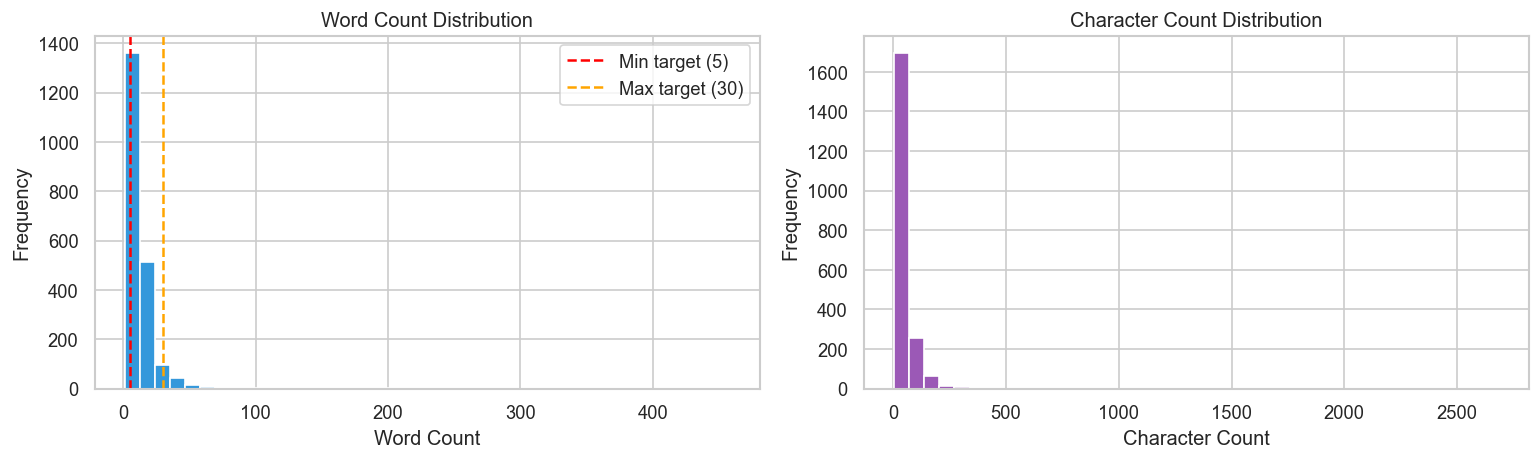

Sentences < 5 words  : 72 (3.5%) — might be noise
Sentences > 30 words : 101  (4.9%) — might be reviews, not questions


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["word_count"], bins=40, color="#3498db", edgecolor="white")
axes[0].axvline(5,  color="red",    linestyle="--", label="Min target (5)")
axes[0].axvline(30, color="orange", linestyle="--", label="Max target (30)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Word Count Distribution")
axes[0].legend()

axes[1].hist(df["char_count"], bins=40, color="#9b59b6", edgecolor="white")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Character Count Distribution")

plt.tight_layout()
plt.savefig(AUDIT_DIR / "sentence_length_distribution.png", bbox_inches="tight")
plt.show()

short = (df["word_count"] < 5).sum()
long  = (df["word_count"] > 30).sum()
print(f"Sentences < 5 words  : {short} ({short/len(df)*100:.1f}%) — might be noise")
print(f"Sentences > 30 words : {long}  ({long/len(df)*100:.1f}%) — might be reviews, not questions")

In [17]:
# Duplicate detection
exact_dups = df.duplicated(subset=["sentence"], keep=False).sum()
near_dups_est = df["sentence"].str.strip().str.lower().duplicated(keep=False).sum()

print(f"Exact duplicate sentences        : {exact_dups}")
print(f"Near-duplicate (case+strip norm) : {near_dups_est}")

if near_dups_est > 0:
    dups = df[df["sentence"].str.strip().str.lower().duplicated(keep=False)]
    print("\nSample duplicates:")
    print(dups[["sample_id", "sentence", "l3"]].head(6).to_string(index=False))

Exact duplicate sentences        : 0
Near-duplicate (case+strip norm) : 0


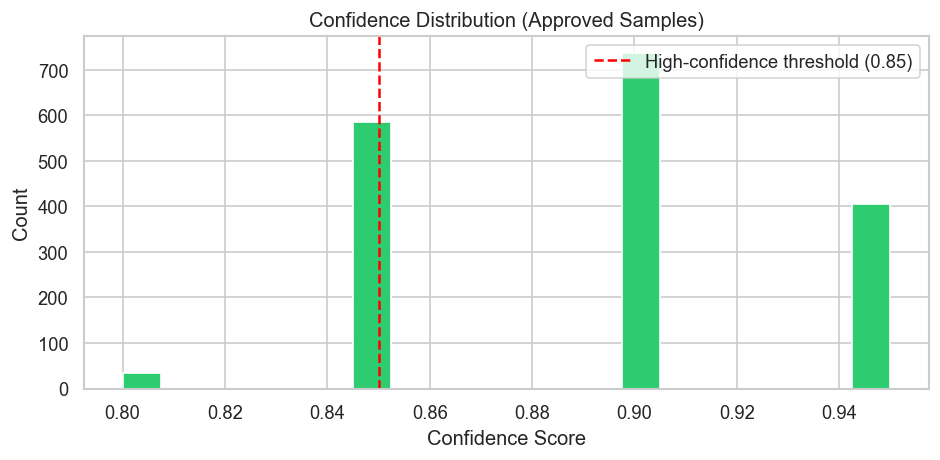

High-confidence samples (≥ 0.85): 1727 / 1761 (98.1%)


In [18]:
# Confidence distribution for approved samples
approved_df = df[df["qa_status"].str.startswith("approved")].copy()
approved_df["confidence"] = pd.to_numeric(approved_df["confidence"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(approved_df["confidence"].dropna(), bins=20, color="#2ecc71", edgecolor="white")
ax.axvline(0.85, color="red", linestyle="--", label="High-confidence threshold (0.85)")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution (Approved Samples)")
ax.legend()
plt.tight_layout()
plt.savefig(AUDIT_DIR / "confidence_distribution.png", bbox_inches="tight")
plt.show()

high_conf = (approved_df["confidence"] >= 0.85).sum()
print(f"High-confidence samples (≥ 0.85): {high_conf} / {len(approved_df)} ({high_conf/len(approved_df)*100:.1f}%)")

## 7. Data Imbalance Analysis

Theo paper plan: không intent nào > 8% tổng dataset.

In [19]:
total = len(df)
BALANCE_CAP_PCT = 8.0

l3_pct = (l3_counts / total * 100).reset_index()
l3_pct.columns = ["l3", "pct"]
over_cap = l3_pct[l3_pct["pct"] > BALANCE_CAP_PCT]

imbalance_ratio = l3_counts.max() / l3_counts.min() if l3_counts.min() > 0 else float("inf")

print(f"Max class count  : {l3_counts.max()} ({l3_counts.idxmax()})")
print(f"Min class count  : {l3_counts.min()} ({l3_counts.idxmin()})")
print(f"Imbalance ratio  : {imbalance_ratio:.1f}x")
print(f"Intents > {BALANCE_CAP_PCT}% share: {len(over_cap)}")

if len(over_cap):
    print(over_cap.to_string(index=False))

Max class count  : 74 (chon_san_pham_phu_hop_cho_da_nhon)
Min class count  : 1 (khieu_nai_trai_nghiem_mua_hang)
Imbalance ratio  : 74.0x
Intents > 8.0% share: 0


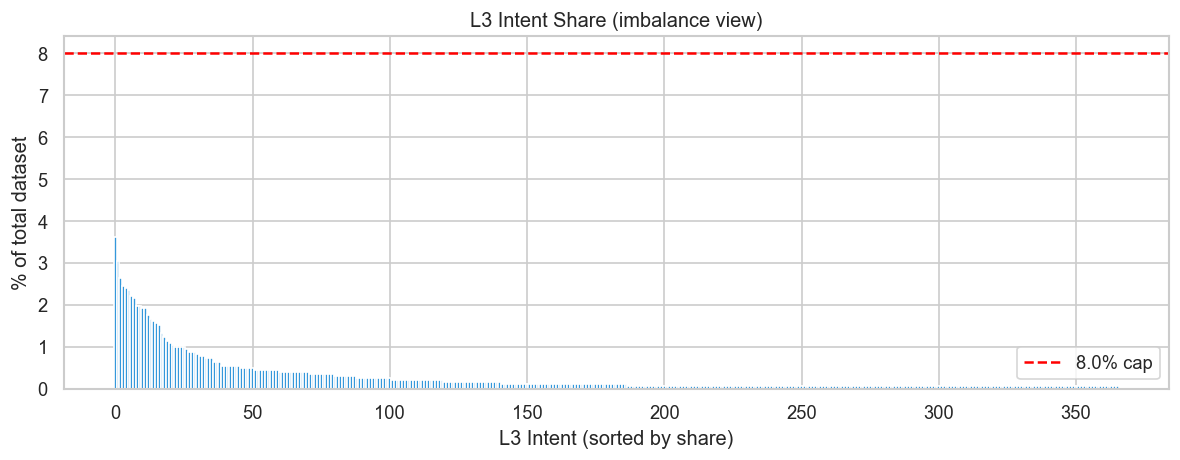

In [20]:
# L3 count vs imbalance visualisation
fig, ax = plt.subplots(figsize=(10, 4))
sorted_pct = l3_pct.sort_values("pct", ascending=False)
bar_colors = ["#e74c3c" if p > BALANCE_CAP_PCT else "#3498db" for p in sorted_pct["pct"]]
ax.bar(range(len(sorted_pct)), sorted_pct["pct"], color=bar_colors, width=1.0)
ax.axhline(BALANCE_CAP_PCT, color="red", linestyle="--", label=f"{BALANCE_CAP_PCT}% cap")
ax.set_xlabel("L3 Intent (sorted by share)")
ax.set_ylabel("% of total dataset")
ax.set_title("L3 Intent Share (imbalance view)")
ax.legend()
plt.tight_layout()
plt.savefig(AUDIT_DIR / "l3_imbalance.png", bbox_inches="tight")
plt.show()

## 8. Data Quality Issues Summary

In [21]:
issues = []

# Invalid slugs
invalid_slug = df[df["qa_status"] == "pending_new_label_invalid_slug"]
issues.append({"issue": "Invalid L3 slug", "count": len(invalid_slug), "action": "Map to valid taxonomy slug"})

# Ambiguous
ambiguous = df[df["qa_status"] == "skipped_ambiguous"]
issues.append({"issue": "Skipped ambiguous", "count": len(ambiguous), "action": "Human review or discard"})

# Needs review
needs_review = df[df["qa_status"].str.contains("needs_review|pending", na=False)]
issues.append({"issue": "Needs human review", "count": len(needs_review), "action": "Claude VERIFY loop"})

# Exact duplicates
issues.append({"issue": "Exact sentence duplicates", "count": exact_dups, "action": "Dedup before split"})

# OOV L3 (not in taxonomy)
oov_count = df[df["l3"].isin(in_data_not_taxonomy)].shape[0]
issues.append({"issue": "L3 not in official taxonomy", "count": oov_count, "action": "Remap or extend taxonomy"})

# Very short sentences
issues.append({"issue": "Sentences < 5 words", "count": short, "action": "Review — may be noise"})

# Missing labels
no_label = df[df["l3"] == ""].shape[0]
issues.append({"issue": "No L3 label assigned", "count": no_label, "action": "Re-run labeling pipeline"})

issues_df = pd.DataFrame(issues)
print("=== Data Quality Issues ===")
print(issues_df.to_string(index=False))

total_issues = sum(i["count"] for i in issues[:-1])  # exclude no_label overlap
print(f"\nEstimated samples with at least one issue: ~{total_issues}")

=== Data Quality Issues ===
                      issue  count                     action
            Invalid L3 slug     25 Map to valid taxonomy slug
          Skipped ambiguous      7    Human review or discard
         Needs human review    275         Claude VERIFY loop
  Exact sentence duplicates      0         Dedup before split
L3 not in official taxonomy   1563   Remap or extend taxonomy
        Sentences < 5 words     72      Review — may be noise
       No L3 label assigned      7   Re-run labeling pipeline

Estimated samples with at least one issue: ~1942


## 9. Export Audit Report

In [22]:
# Full L3 distribution CSV (intent_distribution.csv — paper plan output)
l3_df_sorted = l3_df.sort_values(["l1", "l2", "count"], ascending=[True, True, False])
l3_df_sorted.to_csv(AUDIT_DIR / "intent_distribution.csv", index=False)
print(f"Saved: {AUDIT_DIR / 'intent_distribution.csv'} ({len(l3_df_sorted)} rows)")

# Issues report
issues_df.to_csv(AUDIT_DIR / "quality_issues.csv", index=False)
print(f"Saved: {AUDIT_DIR / 'quality_issues.csv'}")

# Missing taxonomy coverage
missing_df = pd.DataFrame(sorted(in_taxonomy_not_data), columns=["l3_slug_missing"])
missing_df.to_csv(AUDIT_DIR / "taxonomy_missing_coverage.csv", index=False)
print(f"Saved: {AUDIT_DIR / 'taxonomy_missing_coverage.csv'}")

Saved: ../data/audit/intent_distribution.csv (366 rows)
Saved: ../data/audit/quality_issues.csv
Saved: ../data/audit/taxonomy_missing_coverage.csv


In [23]:
# Stats summary JSON (for paper)
summary = {
    "total_samples"         : len(df),
    "usable_approved"       : int(usable.shape[0]),
    "needs_human_review"    : int(needs_review.shape[0]),
    "skipped_ambiguous"     : int(ambiguous.shape[0]),
    "invalid_slug"          : int(invalid_slug.shape[0]),
    "exact_duplicates"      : int(exact_dups),
    "unique_l1"             : int(df["l1"].nunique()),
    "unique_l2"             : int(df["l2"].nunique()),
    "unique_l3_in_data"     : int(len(l3_counts)),
    "unique_l3_in_taxonomy" : int(len(official_l3)),
    "l3_covered"            : int(len(in_taxonomy_and_data)),
    "l3_missing_coverage"   : int(len(in_taxonomy_not_data)),
    "l3_oov_in_data"        : int(len(in_data_not_taxonomy)),
    "intents_sufficient"    : int((l3_df["status"] == "sufficient").sum()),
    "intents_need_augment"  : int((l3_df["status"] == "needs_augmentation").sum()),
    "total_gap_to_fill"     : int(l3_df["gap"].sum()),
    "avg_word_count"        : round(float(df["word_count"].mean()), 2),
    "avg_char_count"        : round(float(df["char_count"].mean()), 2),
    "l1_before_sale"        : int((df["l1"] == "truoc_mua_hang").sum()),
    "l1_after_sale"         : int((df["l1"] == "sau_mua_hang").sum()),
    "imbalance_ratio"       : round(float(imbalance_ratio), 2),
}

with open(AUDIT_DIR / "dataset_stats.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("=== DATASET AUDIT SUMMARY ===")
for k, v in summary.items():
    print(f"  {k:<35}: {v}")

print(f"\nSaved: {AUDIT_DIR / 'dataset_stats.json'}")

=== DATASET AUDIT SUMMARY ===
  total_samples                      : 2043
  usable_approved                    : 1761
  needs_human_review                 : 275
  skipped_ambiguous                  : 7
  invalid_slug                       : 25
  exact_duplicates                   : 0
  unique_l1                          : 5
  unique_l2                          : 56
  unique_l3_in_data                  : 366
  unique_l3_in_taxonomy              : 109
  l3_covered                         : 55
  l3_missing_coverage                : 54
  l3_oov_in_data                     : 311
  intents_sufficient                 : 17
  intents_need_augment               : 349
  total_gap_to_fill                  : 9184
  avg_word_count                     : 12.99
  avg_char_count                     : 53.49
  l1_before_sale                     : 1596
  l1_after_sale                      : 433
  imbalance_ratio                    : 74.0

Saved: ../data/audit/dataset_stats.json


## 10. Phase Readiness Checklist

Theo `docs/paper_plan.md` — Phase 1 Data Audit checklist:

In [24]:
checks = [
    (True,  "Export toàn bộ labels từ pipeline"),
    (True,  "Vẽ distribution plot: số mẫu per L3 intent"),
    (True,  "Xác định intents thiếu (< 30 mẫu train)"),
    (True,  "Xác định intents thừa (> 200 mẫu)"),
    (True,  "Tính tỷ lệ approved / needs_review / rejected"),
    (True,  "Tạo intent_distribution.csv"),
    (False, "Vẽ confusion matrix (cần baseline model)"),
    (False, "Tính Cohen's κ inter-annotator agreement"),
    (False, "Lock test set 1,000 câu (Phase 2)"),
    (False, "Chạy Claude VERIFY loop (Phase 2)"),
]

print("Phase 1 — Data Audit Checklist")
print("=" * 50)
for done, task in checks:
    mark = "[x]" if done else "[ ]"
    print(f"  {mark}  {task}")

done_count = sum(1 for d, _ in checks if d)
print(f"\n  {done_count}/{len(checks)} tasks complete")

Phase 1 — Data Audit Checklist
  [x]  Export toàn bộ labels từ pipeline
  [x]  Vẽ distribution plot: số mẫu per L3 intent
  [x]  Xác định intents thiếu (< 30 mẫu train)
  [x]  Xác định intents thừa (> 200 mẫu)
  [x]  Tính tỷ lệ approved / needs_review / rejected
  [x]  Tạo intent_distribution.csv
  [ ]  Vẽ confusion matrix (cần baseline model)
  [ ]  Tính Cohen's κ inter-annotator agreement
  [ ]  Lock test set 1,000 câu (Phase 2)
  [ ]  Chạy Claude VERIFY loop (Phase 2)

  6/10 tasks complete


## 11. Next Steps

Dựa trên audit kết quả, các việc cần làm theo thứ tự ưu tiên:

1. **Remap OOV L3 slugs** — `in_data_not_taxonomy` chứa các nhãn không có trong taxonomy chính thức. Cần map về đúng slug hoặc mở rộng taxonomy.

2. **Chạy Claude VERIFY loop** cho `needs_review` + `pending_*` samples (khoảng 275 câu).

3. **Build test set** — chọn stratified 1,000 câu từ approved samples, lock khỏi training.

4. **Augment thiếu mẫu** — chạy Claude GENERATE cho các L3 intents có < 30 mẫu.

5. **Cân bằng dataset** — down-sample intents > 200 mẫu về 150 (random seed=42).

6. **Expand coverage** — thêm mẫu cho `in_taxonomy_not_data` intents (hiện chưa có data).